# Medusa Throughput Ablation Analysis

This notebook builds per-batch heatmaps of mean accepted tokens per sequence for MEDUSA runs.

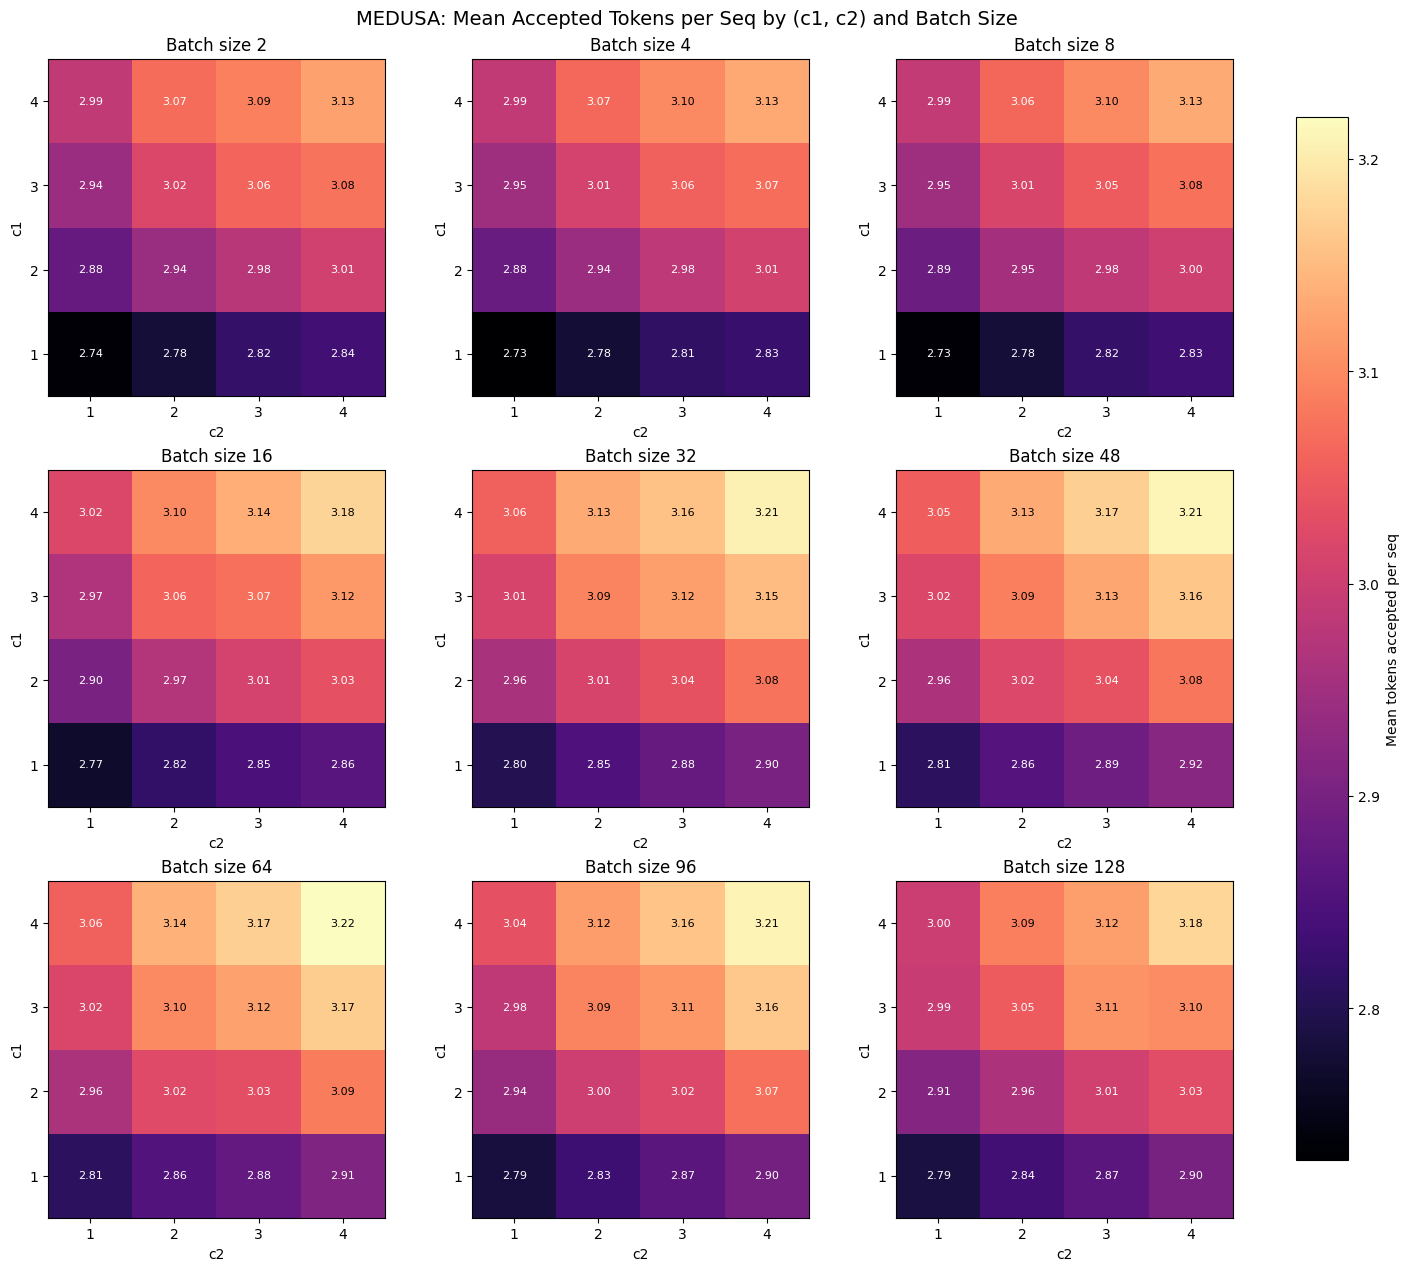

,bs,c1,c2,mean_tokens_accepted_per_seq
32,2,1,1,2.736229
33,2,1,2,2.778985
34,2,1,3,2.819016
35,2,1,4,2.835189
36,2,2,1,2.879266


In [49]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('bench_csvs/medusa')
PATTERN = re.compile(r'^medusa_bs(?P<bs>\d+)_c1_(?P<c1>\d+)_c2_(?P<c2>\d+)_n128\.data\.csv$')
TARGET_COL = 'mean_tokens_accepted_per_seq'

records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if TARGET_COL not in df.columns:
        continue

    # Ignore sentinel values from non-decode steps.
    vals = pd.to_numeric(df[TARGET_COL], errors='coerce')
    vals = vals[vals >= 0]
    mean_val = float(vals.mean()) if len(vals) else np.nan

    records.append({'bs': bs, 'c1': c1, 'c2': c2, 'mean_tokens_accepted_per_seq': mean_val})

agg = pd.DataFrame(records)
if agg.empty:
    raise RuntimeError('No MEDUSA CSVs with the target column were found.')

batch_sizes = sorted(agg['bs'].unique())
n = len(batch_sizes)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

vmin = agg['mean_tokens_accepted_per_seq'].min()
vmax = agg['mean_tokens_accepted_per_seq'].max()

im = None
for i, bs in enumerate(batch_sizes):
    ax = axes[i]
    sub = agg[agg['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values='mean_tokens_accepted_per_seq').reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im = ax.imshow(mat.values, origin='lower', cmap='magma', vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im.cmap(im.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

if im is not None:
    cbar = fig.colorbar(im, ax=axes[:n], shrink=0.9)
    cbar.set_label('Mean tokens accepted per seq')

fig.suptitle('MEDUSA: Mean Accepted Tokens per Seq by (c1, c2) and Batch Size', fontsize=14)
plt.show()

agg.sort_values(['bs', 'c1', 'c2']).head()

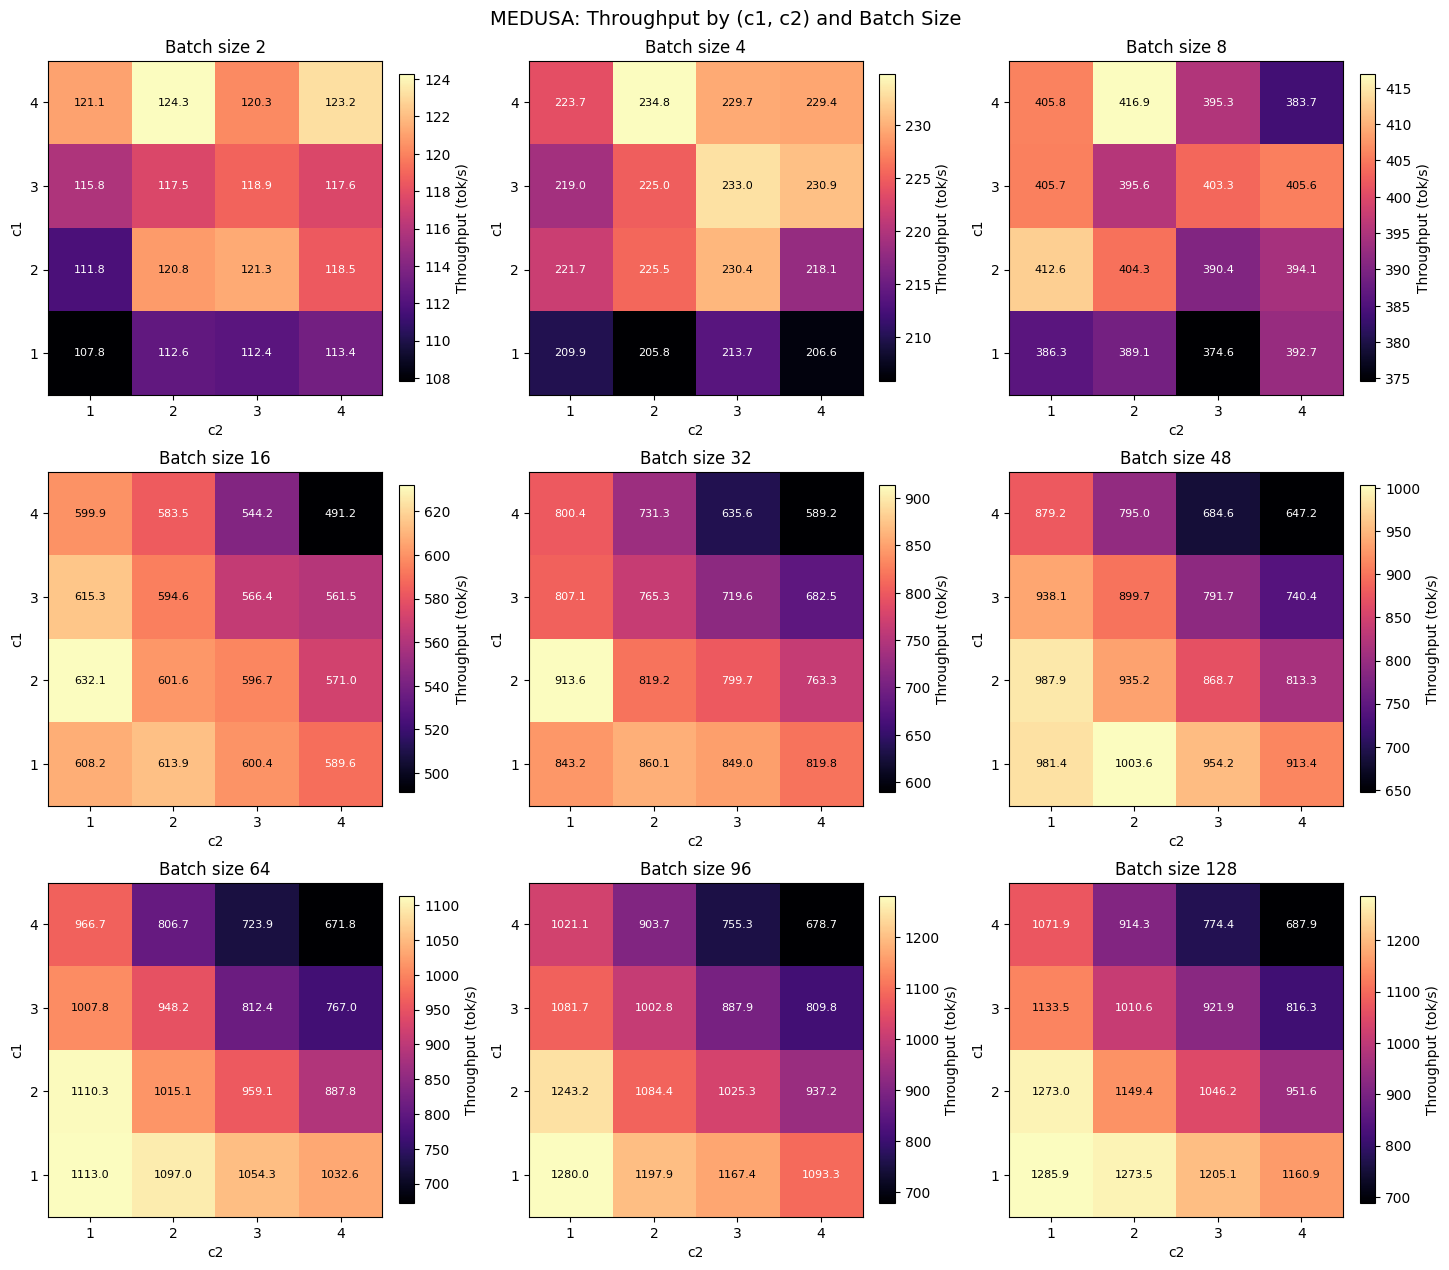

,bs,c1,c2,throughput_tok_s
32,2,1,1,107.822212
33,2,1,2,112.636798
34,2,1,3,112.379209
35,2,1,4,113.381998
36,2,2,1,111.763696


In [50]:
# Throughput heatmaps by batch size (computed from timestamps and total tokens)

THROUGHPUT_COL = 'throughput_tok_s'

t_records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if 'total_generated_tokens' not in df.columns or 'timestamp' not in df.columns or df.empty:
        continue

    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        continue

    t0 = float(ts.iloc[0])
    t1 = float(ts.iloc[-1])
    total = float(tg.iloc[-1])

    elapsed = t1 - t0
    throughput = (total / elapsed) if elapsed > 0 else np.nan

    t_records.append({'bs': bs, 'c1': c1, 'c2': c2, THROUGHPUT_COL: throughput})

thr = pd.DataFrame(t_records)
if thr.empty:
    raise RuntimeError('No MEDUSA CSVs with timestamp/total_generated_tokens were found.')

batch_sizes_t = sorted(thr['bs'].unique())
n_t = len(batch_sizes_t)
ncols_t = 3
nrows_t = (n_t + ncols_t - 1) // ncols_t

fig, axes = plt.subplots(nrows_t, ncols_t, figsize=(4.8 * ncols_t, 4.2 * nrows_t), constrained_layout=True)
axes = np.array(axes).reshape(-1)

im_t = None
for i, bs in enumerate(batch_sizes_t):
    ax = axes[i]
    sub = thr[thr['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values=THROUGHPUT_COL).reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im_t = ax.imshow(mat.values, origin='lower', cmap='magma', aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im_t.cmap(im_t.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

for i, bs in enumerate(batch_sizes_t):
    if i < len(axes) and axes[i].images:
        cbar = fig.colorbar(axes[i].images[0], ax=axes[i], shrink=0.9)
        cbar.set_label('Throughput (tok/s)')

fig.suptitle('MEDUSA: Throughput by (c1, c2) and Batch Size', fontsize=14)
plt.show()

thr.sort_values(['bs', 'c1', 'c2']).head()


# No SpecDec vs SpecDec Throughput Analysis

This section compares the throughput of regular SpecDec runs with runs that have no Speculative Decoding.

## Throughput vs Batch Size (None vs Naive)
Plot end-to-end throughput (from CSV timestamps and final total tokens) for no-spec and naive speculative decoding across batch sizes.

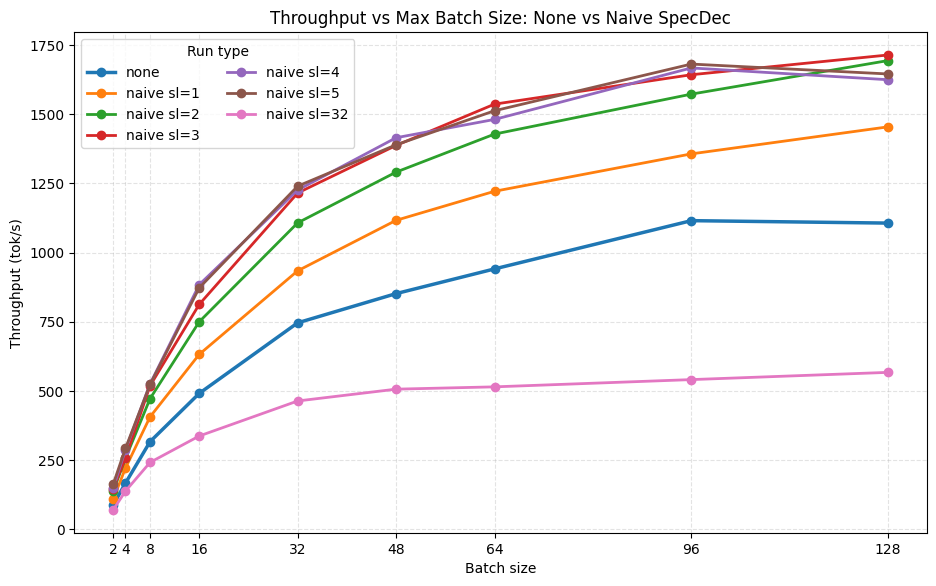

,method,spec_len,bs,throughput
11,naive,1,2,108.708300
13,naive,1,4,221.357327
16,naive,1,8,406.761928
10,naive,1,16,632.533676
12,naive,1,32,934.203087
...,...,...,...,...
3,none,0,32,746.365040
5,none,0,48,851.856889
6,none,0,64,941.058953
8,none,0,96,1115.366755


In [51]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NONE_DIR = Path('bench_csvs/none')
NAIVE_DIR = Path('bench_csvs/naive')

pat_none = re.compile(r'^none-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')

def throughput_from_csv(path: Path) -> float:
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        return np.nan
    elapsed = float(ts.iloc[-1]) - float(ts.iloc[0])
    total = float(tg.iloc[-1])
    return total / elapsed if elapsed > 0 else np.nan

rows = []

for p in sorted(NONE_DIR.glob('none-bs_*-n128-*.data.csv')):
    m = pat_none.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'none', 'spec_len': 0, 'bs': bs, 'throughput': thr, 'file': p.name})

for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    sl = int(m.group('sl'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'naive', 'spec_len': sl, 'bs': bs, 'throughput': thr, 'file': p.name})

plot_df = pd.DataFrame(rows)
if plot_df.empty:
    raise RuntimeError('No none/naive benchmark CSVs found.')

plot_df = plot_df.sort_values(['method', 'spec_len', 'bs'])

fig, ax = plt.subplots(figsize=(11, 6.5))

none_df = plot_df[plot_df['method'] == 'none'].sort_values('bs')
ax.plot(
    none_df['bs'],
    none_df['throughput'],
    marker='o',
    linewidth=2.5,
    label='none',
)

for sl in sorted(plot_df.loc[plot_df['method'] == 'naive', 'spec_len'].unique()):
    sub = plot_df[(plot_df['method'] == 'naive') & (plot_df['spec_len'] == sl)].sort_values('bs')
    ax.plot(
        sub['bs'],
        sub['throughput'],
        marker='o',
        linewidth=2,
        label=f'naive sl={sl}',
    )

ax.set_xticks(sorted(plot_df['bs'].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Batch size')
ax.set_ylabel('Throughput (tok/s)')
ax.set_title('Throughput vs Max Batch Size: None vs Naive SpecDec')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(title='Run type', ncol=2)
plt.show()

plot_df[['method', 'spec_len', 'bs', 'throughput']].sort_values(['method', 'spec_len', 'bs'])


## Naive SpecDec Heatmap (Throughput)
Rows are speculation length, columns are batch size, and cell color is throughput.

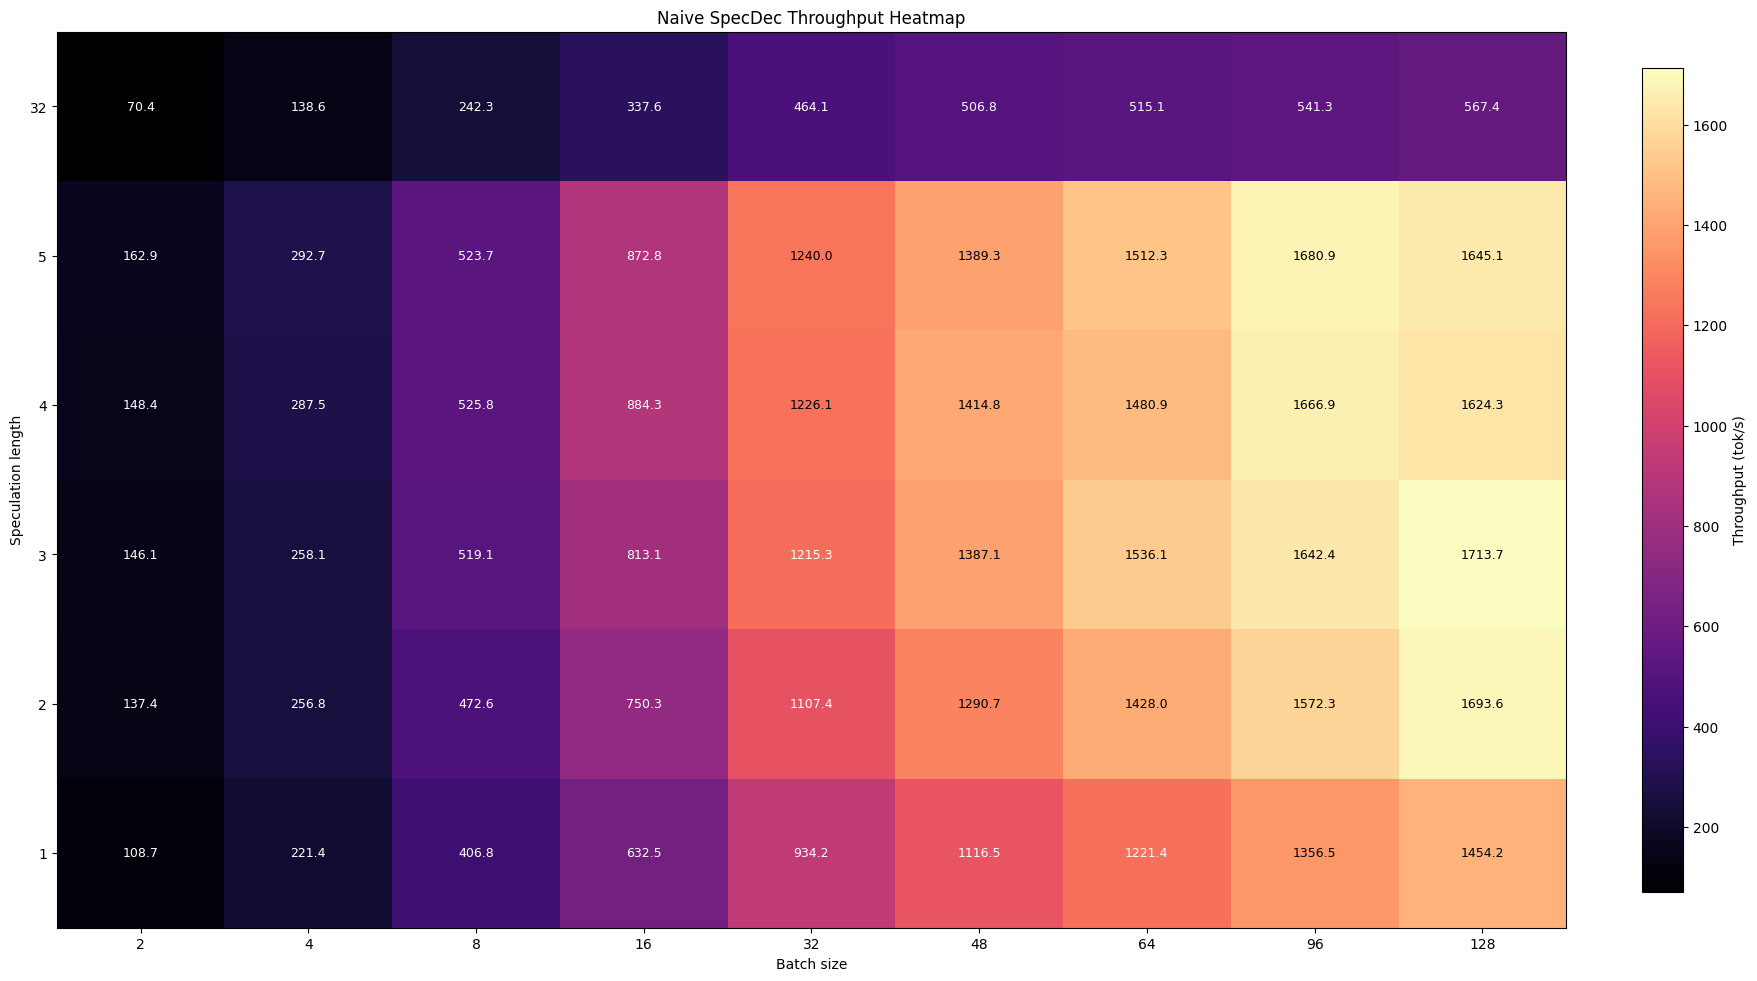

bs,2,4,8,16,32,48,64,96,128
spec_len,,,,,,,,,
1,108.708300,221.357327,406.761928,632.533676,934.203087,1116.532692,1221.416255,1356.538228,1454.220940
2,137.399971,256.830662,472.567672,750.279563,1107.434721,1290.675110,1427.950837,1572.333457,1693.606426
3,146.076906,258.087314,519.093076,813.089236,1215.327771,1387.052434,1536.111990,1642.395931,1713.734990
4,148.379939,287.454963,525.756934,884.290708,1226.100178,1414.830037,1480.928106,1666.879511,1624.316492
5,162.911536,292.664717,523.690376,872.836480,1239.980676,1389.297946,1512.260584,1680.907851,1645.125950
32,70.443203,138.561680,242.265650,337.623813,464.128434,506.781832,515.110864,541.292916,567.445428


In [52]:
# Naive: throughput heatmap (spec length x batch size)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAIVE_DIR = Path('bench_csvs/naive')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')

def throughput_from_csv(path: Path) -> float:
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        return np.nan
    elapsed = float(ts.iloc[-1]) - float(ts.iloc[0])
    total = float(tg.iloc[-1])
    return total / elapsed if elapsed > 0 else np.nan

rows = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    sl = int(m.group('sl'))
    bs = int(m.group('bs'))
    rows.append({'spec_len': sl, 'bs': bs, 'throughput': throughput_from_csv(p)})

naive_df = pd.DataFrame(rows)
if naive_df.empty:
    raise RuntimeError('No naive benchmark CSVs found for heatmap.')

spec_lens = sorted(naive_df['spec_len'].unique())
batch_sizes = sorted(naive_df['bs'].unique())

mat = naive_df.pivot(index='spec_len', columns='bs', values='throughput').reindex(index=spec_lens, columns=batch_sizes)

fig, ax = plt.subplots(figsize=(1.5 * len(batch_sizes) + 4, 1.2 * len(spec_lens) + 2.5), constrained_layout=True)
im = ax.imshow(mat.values, origin='lower', cmap='magma', aspect='auto')

ax.set_title('Naive SpecDec Throughput Heatmap')
ax.set_xlabel('Batch size')
ax.set_ylabel('Speculation length')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels(batch_sizes)
ax.set_yticks(range(len(spec_lens)))
ax.set_yticklabels(spec_lens)

for r in range(len(spec_lens)):
    for c in range(len(batch_sizes)):
        val = mat.values[r, c]
        if np.isfinite(val):
            rgba = im.cmap(im.norm(val))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            txt_color = 'black' if luminance > 0.55 else 'white'
            ax.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.92)
cbar.set_label('Throughput (tok/s)')

plt.show()

mat


## Naive SpecDec Heatmap (Mean Accepted Tokens per Sequence)
Rows are speculation length, columns are batch size, and cell color is run-level mean of `mean_tokens_accepted_per_seq`.

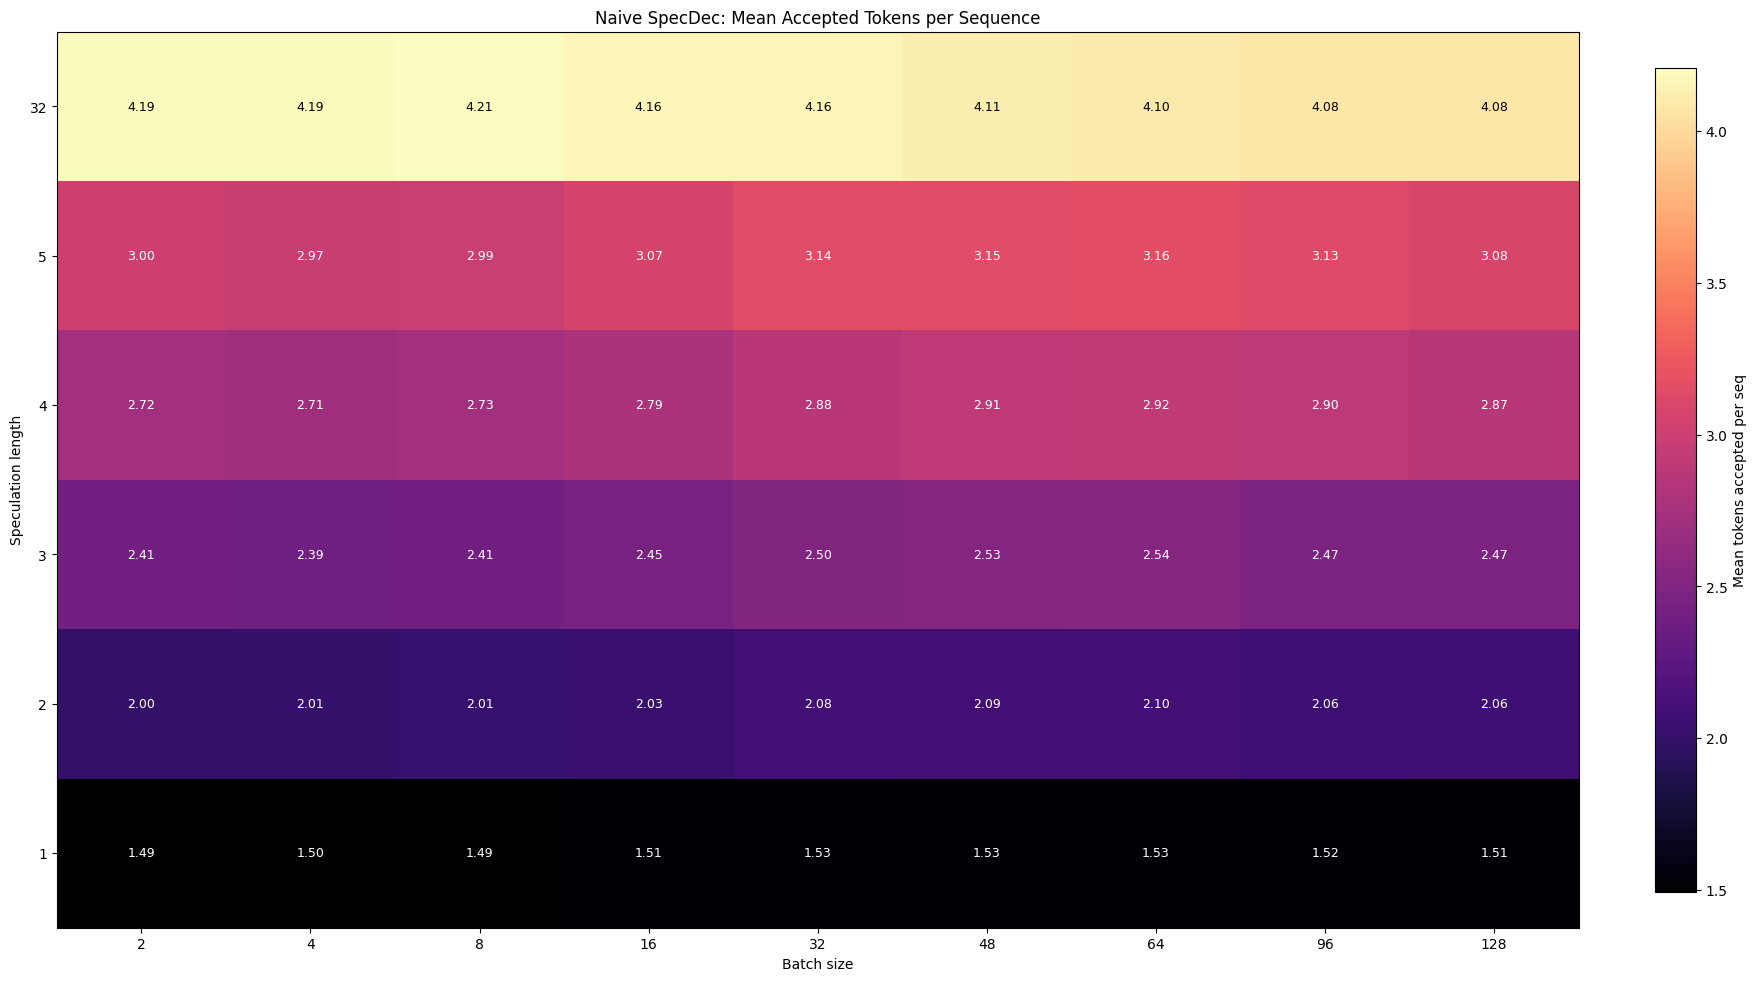

bs,2,4,8,16,32,48,64,96,128
spec_len,,,,,,,,,
1,1.494817,1.497407,1.494447,1.508590,1.525787,1.525029,1.528200,1.519911,1.514579
2,2.002892,2.011135,2.014689,2.031209,2.077740,2.089635,2.098233,2.058206,2.057668
3,2.410251,2.393247,2.406824,2.445434,2.504287,2.525639,2.536994,2.470976,2.472071
4,2.724652,2.711687,2.730276,2.792101,2.881873,2.907607,2.915382,2.899368,2.865489
5,2.999712,2.970740,2.992028,3.070758,3.140090,3.152782,3.160782,3.128741,3.080438
32,4.191503,4.190377,4.208043,4.156317,4.161818,4.114378,4.098894,4.077064,4.075674


In [53]:
# Naive: mean accepted tokens (MAT) heatmap (spec length x batch size)
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAIVE_DIR = Path('bench_csvs/naive')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')
TARGET_COL = 'mean_tokens_accepted_per_seq'

rows = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    sl = int(m.group('sl'))
    bs = int(m.group('bs'))

    df = pd.read_csv(p)
    if TARGET_COL not in df.columns:
        continue

    vals = pd.to_numeric(df[TARGET_COL], errors='coerce')
    vals = vals[vals >= 0]  # ignore sentinel rows
    mat_value = float(vals.mean()) if len(vals) else np.nan

    rows.append({'spec_len': sl, 'bs': bs, 'mat': mat_value, 'file': p.name})

mat_df = pd.DataFrame(rows)
if mat_df.empty:
    raise RuntimeError('No naive CSVs with mean_tokens_accepted_per_seq found.')

spec_lens = sorted(mat_df['spec_len'].unique())
batch_sizes = sorted(mat_df['bs'].unique())

pivot = mat_df.pivot(index='spec_len', columns='bs', values='mat').reindex(index=spec_lens, columns=batch_sizes)

fig, ax = plt.subplots(figsize=(1.5 * len(batch_sizes) + 4, 1.2 * len(spec_lens) + 2.5), constrained_layout=True)
im = ax.imshow(pivot.values, origin='lower', cmap='magma', aspect='auto')

ax.set_title('Naive SpecDec: Mean Accepted Tokens per Sequence')
ax.set_xlabel('Batch size')
ax.set_ylabel('Speculation length')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels(batch_sizes)
ax.set_yticks(range(len(spec_lens)))
ax.set_yticklabels(spec_lens)

for r in range(len(spec_lens)):
    for c in range(len(batch_sizes)):
        val = pivot.values[r, c]
        if np.isfinite(val):
            rgba = im.cmap(im.norm(val))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            txt_color = 'black' if luminance > 0.55 else 'white'
            ax.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.92)
cbar.set_label('Mean tokens accepted per seq')

plt.show()

pivot


## Naive specdec Speedup vs Baseline (None)
Speedup is computed as throughput divided by the no-spec (`none`) throughput at the same batch size.

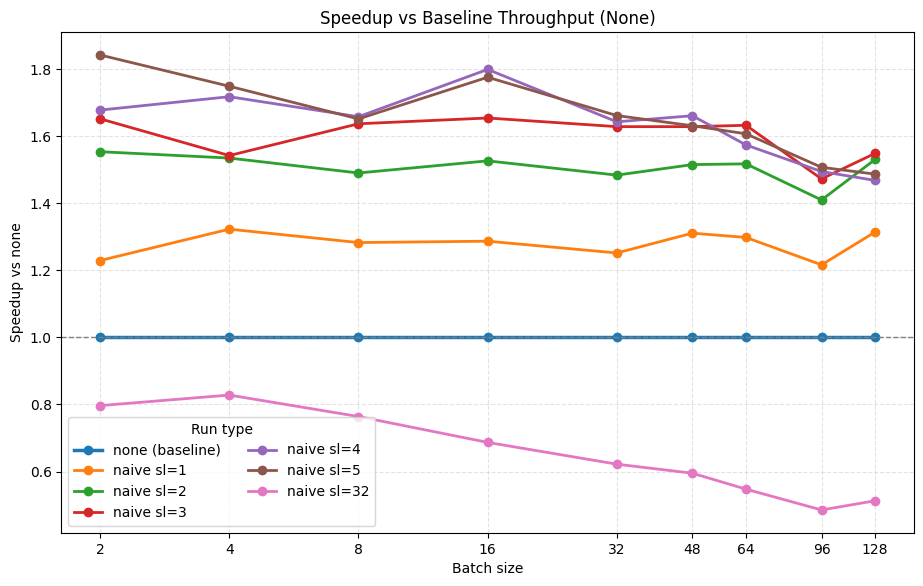

,method,spec_len,bs,throughput,baseline_tput,speedup
0,naive,1,2,108.708300,88.442308,1.229144
1,naive,1,4,221.357327,167.357871,1.322659
2,naive,1,8,406.761928,317.125182,1.282654
3,naive,1,16,632.533676,491.569003,1.286765
4,naive,1,32,934.203087,746.365040,1.251670
...,...,...,...,...,...,...
58,none,0,32,746.365040,746.365040,1.000000
59,none,0,48,851.856889,851.856889,1.000000
60,none,0,64,941.058953,941.058953,1.000000
61,none,0,96,1115.366755,1115.366755,1.000000


In [54]:
# Speedup vs baseline (none) using plot_df from the previous section
# Requires: plot_df with columns [method, spec_len, bs, throughput]

if 'plot_df' not in globals():
    raise RuntimeError("Run the 'Throughput vs Batch Size (None vs Naive)' cell first.")

base = (
    plot_df[plot_df['method'] == 'none'][['bs', 'throughput']]
    .rename(columns={'throughput': 'baseline_tput'})
)

spd = plot_df.merge(base, on='bs', how='inner').copy()
spd['speedup'] = spd['throughput'] / spd['baseline_tput']

fig, ax = plt.subplots(figsize=(11, 6.5))

# Baseline line should be exactly 1.0
none_spd = spd[spd['method'] == 'none'].sort_values('bs')
ax.plot(
    none_spd['bs'],
    none_spd['speedup'],
    marker='o',
    linewidth=2.5,
    label='none (baseline)',
)

for sl in sorted(spd.loc[spd['method'] == 'naive', 'spec_len'].unique()):
    sub = spd[(spd['method'] == 'naive') & (spd['spec_len'] == sl)].sort_values('bs')
    ax.plot(
        sub['bs'],
        sub['speedup'],
        marker='o',
        linewidth=2,
        label=f'naive sl={sl}',
    )

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xscale('log', base=2)
ax.set_xticks(sorted(spd['bs'].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Batch size')
ax.set_ylabel('Speedup vs none')
ax.set_title('Speedup vs Baseline Throughput (None)')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(title='Run type', ncol=2)
plt.show()

spd[['method', 'spec_len', 'bs', 'throughput', 'baseline_tput', 'speedup']].sort_values(['method', 'spec_len', 'bs'])
